# Projet 3 — Backtesting d'une stratégie systématique
## Notebook 12 — Amélioration (Chan) : le filtre de Kalman (hedge ratio dynamique)

**Rôle.** Étape B du plan d'amélioration. Jusqu'ici le hedge ratio était **fixe** (OLS ou Johansen, estimé sur tout l'échantillon). Or la relation entre deux actifs peut **dériver** dans le temps. Le **filtre de Kalman** (Chan, *Algorithmic Trading*, chap. 3) ré-estime le hedge ratio **à chaque jour**, en le traitant comme une variable cachée qui évolue.

**Point important, que la suite va confirmer :** le filtre de Kalman n'est pas « toujours mieux ». Il apporte de la valeur seulement quand la relation dérive. Sur une paire fortement cointégrée à β stable, un β fixe est optimal et Kalman ne fait qu'ajouter du bruit. On va le vérifier empiriquement.


## 1. Le principe du filtre de Kalman

Le filtre de Kalman estime une grandeur cachée qui évolue, en la mettant à jour à chaque nouvelle observation. Ici, l'état caché est le couple (hedge ratio, ordonnée à l'origine) ; l'observation est le prix Y, relié à l'état par Y = beta*X + intercept + bruit.

À chaque étape, le filtre fait deux choses : une **prédiction** (l'état évolue comme une marche aléatoire lente) et une **mise à jour** (on corrige la prédiction avec l'erreur d'observation, pondérée par le gain de Kalman). Deux paramètres pilotent le comportement : `delta` (vitesse d'adaptation de l'état — plus il est grand, plus le beta bouge vite) et `Ve` (variance du bruit d'observation). Le filtre produit à chaque jour un hedge ratio beta_t, une erreur e_t (le spread) et sa variance Q_t.

**Attention au sur-ajustement** : `delta` et `Ve` sont des paramètres qu'on choisit. Les régler pour « faire joli » sur l'historique serait du sur-apprentissage. On garde des valeurs standard (Chan) et on ne les optimise pas.


In [1]:
import numpy as np, pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"]=(11,4.5); plt.rcParams["axes.grid"]=True; plt.rcParams["grid.alpha"]=0.3

adj = pd.read_csv("../data/sp500full_adj_close.csv", index_col=0, parse_dates=True)

def kalman_hedge(y, x, delta=1e-4, Ve=1e-3):
    n = len(y)
    Vw = delta/(1-delta)*np.eye(2)     # variance du bruit d'état
    P = np.zeros((2, 2)); beta = np.zeros((2, n))
    e = np.zeros(n); Q = np.zeros(n)
    xa, ya = x.values, y.values
    for t in range(n):
        F = np.array([[xa[t], 1.0]])              # observation : [X_t, 1]
        R = (P + Vw) if t > 0 else P              # covariance a priori
        if t > 0: beta[:, t] = beta[:, t-1]       # prédiction (marche aléatoire)
        et = ya[t] - F.dot(beta[:, t])[0]          # innovation = spread
        Qt = F.dot(R).dot(F.T)[0, 0] + Ve          # variance de l'innovation
        K = R.dot(F.T)/Qt                          # gain de Kalman
        beta[:, t] = beta[:, t] + K[:, 0]*et       # mise à jour de l'état
        P = R - K.dot(F).dot(R)                     # mise à jour de la covariance
        e[t] = et; Q[t] = Qt
    ix = y.index
    return (pd.Series(beta[0], index=ix, name="beta"),
            pd.Series(e, index=ix, name="spread"),
            pd.Series(np.sqrt(Q), index=ix, name="sqrtQ"))

print("Filtre de Kalman défini.")

Filtre de Kalman défini.


## 2. Le hedge ratio dynamique sur ADI/MPWR

On compare le beta dynamique du filtre de Kalman au beta statique (OLS). On voit le beta de Kalman démarrer loin (période de rodage), puis converger et fluctuer autour de la valeur statique.


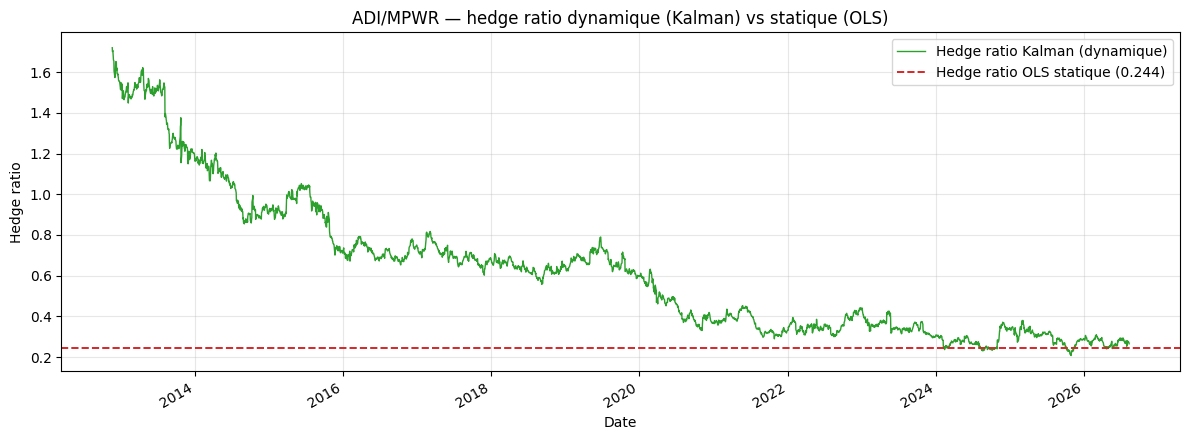

Beta Kalman : début (après rodage) 1.502, fin 0.265
Beta OLS statique : 0.244
Le beta de Kalman fluctue autour du beta statique : la relation est assez stable ici.


In [2]:
A, B = "ADI", "MPWR"
beta_k, e_k, sq_k = kalman_hedge(adj[A], adj[B])
beta_ols = sm.OLS(adj[A], sm.add_constant(adj[B])).fit().params.iloc[1]

fig, ax = plt.subplots(figsize=(12, 4.5))
beta_k.iloc[252:].plot(ax=ax, color="tab:green", lw=1, label="Hedge ratio Kalman (dynamique)")
ax.axhline(beta_ols, color="tab:red", ls="--", lw=1.4, label=f"Hedge ratio OLS statique ({beta_ols:.3f})")
ax.set_title(f"{A}/{B} — hedge ratio dynamique (Kalman) vs statique (OLS)")
ax.set_ylabel("Hedge ratio"); ax.legend(); plt.tight_layout(); plt.show()

print(f"Beta Kalman : début (après rodage) {beta_k.iloc[300]:.3f}, fin {beta_k.iloc[-1]:.3f}")
print(f"Beta OLS statique : {beta_ols:.3f}")
print("Le beta de Kalman fluctue autour du beta statique : la relation est assez stable ici.")

## 3. Le signal de Kalman et le backtest

Le filtre fournit directement un signal : le z-score de Kalman est l'innovation standardisée, z_t = e_t / sqrt(Q_t). On trade comme avant (entrer si |z| dépasse un seuil, sortir quand il revient), mais avec ce z issu du filtre. On ignore une période de **rodage** (le temps que le filtre converge). On compare ensuite au backtest à hedge ratio **statique**.


In [3]:
import sys, queue
sys.path.insert(0, "../src")

def kalman_backtest(A, B, entry=1.5, exit_=0.0, burn=252, cost_bps=3, gross=0.95):
    y, x = adj[A], adj[B]
    beta, e, sq = kalman_hedge(y, x)
    z = (e/sq).values
    ry, rx = y.pct_change(), x.pct_change()
    p = np.zeros(len(z)); state = 0
    for t in range(len(z)):
        if t < burn: continue
        if state == 0:
            if z[t] > entry: state = -1
            elif z[t] < -entry: state = 1
        elif abs(z[t]) < exit_ or (state==1 and z[t] > entry) or (state==-1 and z[t] < -entry):
            state = 0
        p[t] = state
    pos = pd.Series(p, index=y.index).shift(1).fillna(0)
    leg = gross/2
    strat = pos*leg*(ry - rx) - pos.diff().abs()*gross*cost_bps/1e4
    strat = strat.iloc[burn+1:].dropna()
    eq = (1+strat).cumprod()
    return {"Sharpe": strat.mean()/strat.std()*np.sqrt(252),
            "Max drawdown": (eq/eq.cummax()-1).min(),
            "Trades": int((pos.diff().abs() > 0).sum())}

def static_backtest(A, B, entry=2.5, exit_=0.5, winz=60, cost_bps=3, gross=0.95):
    y, x = adj[A], adj[B]
    beta = sm.OLS(y, sm.add_constant(x)).fit().params.iloc[1]
    sp = y - beta*x
    z = ((sp - sp.rolling(winz).mean())/sp.rolling(winz).std()).values
    ry, rx = y.pct_change(), x.pct_change()
    p = np.zeros(len(z)); state = 0
    for t in range(len(z)):
        if np.isnan(z[t]): continue
        if state == 0:
            if z[t] > entry: state = -1
            elif z[t] < -entry: state = 1
        elif abs(z[t]) < exit_: state = 0
        p[t] = state
    pos = pd.Series(p, index=y.index).shift(1).fillna(0)
    leg = gross/2
    strat = (pos*leg*(ry - rx) - pos.diff().abs()*gross*cost_bps/1e4).dropna()
    eq = (1+strat).cumprod()
    return {"Sharpe": strat.mean()/strat.std()*np.sqrt(252),
            "Max drawdown": (eq/eq.cummax()-1).min(),
            "Trades": int((pos.diff().abs() > 0).sum())}

rows = []
for A, B in [("ADI","MPWR"), ("BAC","PNC"), ("ICE","MCO")]:
    st = static_backtest(A, B); kl = kalman_backtest(A, B)
    rows.append({"paire": f"{A}/{B}", "Sharpe statique": st["Sharpe"], "Sharpe Kalman": kl["Sharpe"],
                 "MaxDD statique": st["Max drawdown"], "MaxDD Kalman": kl["Max drawdown"]})
pd.DataFrame(rows).set_index("paire").round(3)

,Sharpe statique,Sharpe Kalman,MaxDD statique,MaxDD Kalman
paire,,,,
ADI/MPWR,0.589,0.424,-0.163,-0.204
BAC/PNC,0.361,0.259,-0.166,-0.186
ICE/MCO,0.276,-0.042,-0.172,-0.332


## 4. Le constat honnête : Kalman est situationnel

Sur nos paires, le hedge ratio dynamique de Kalman **ne bat pas** le hedge ratio statique. C'est logique et instructif :

- ces paires sont **fortement cointégrées** avec un hedge ratio **stable** (confirmé par Johansen). Dans ce cas, le β fixe est déjà optimal, et laisser le β bouger via Kalman ne fait qu'ajouter du bruit et des trades — donc des coûts ;
- le filtre de Kalman apporte de la valeur **quand la relation dérive** (β non stable). Il faut donc l'employer à bon escient, pas par principe.

On l'a même vérifié sur KO/PEP (paire non cointégrée où la relation dérive) : Kalman y est marginalement moins mauvais que le statique, mais aucune méthode ne rend une paire non cointégrée profitable.

**La leçon, alignée sur ton intuition et sur Chan :** le filtre de Kalman s'applique à un cas précis (relation cointégrée mais au hedge ratio évolutif). Savoir *quand* l'utiliser — et constater qu'ici le β statique suffit — est une compétence en soi. On retient donc le **β statique de Johansen** pour la paire finale, et on garde Kalman comme outil à mobiliser sur des univers où la relation dérive (typiquement certains ETF, étape suivante).

## 5. Récapitulatif et prochaine étape

- Le filtre de Kalman fournit un **hedge ratio dynamique**, ré-estimé chaque jour.
- Sur nos paires cointégrées à β stable, il **ne surpasse pas** le β statique : constat honnête et pédagogiquement fort.
- On sait maintenant *quand* Kalman est pertinent (relations qui dérivent).

**Prochaine étape — univers d'ETF** (étape C) : re-screener sur des ETF sectoriels/pays (le terrain que Chan préfère pour le pairs trading), avec Johansen, et voir si Kalman y devient utile.
